In [1]:
''' imports libraries '''

# misc
import pandas as pd # Import Pandas for data manipulation using dataframes
import numpy as np # Import Numpy for data statistical analysis 
import matplotlib.pyplot as plt # Import matplotlib for data visualisation
import seaborn as sns
import random
from currency_converter import CurrencyConverter, ECB_URL
from datetime import datetime
import urllib.request # for obtaining currency data

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Keras
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

# FEATURE ENGINEERING

In [2]:
''' defines functions for feature transformation '''

def one_hot_encode(feature):
    global df_enabled

    if not feature in df_enabled.columns: 
        print(f'WARN: tried to one-hot encode missing feature {feature}')
        return

    # prefix appends feature name to each categorie's column
    one_hot = pd.get_dummies(df_enabled[feature], prefix=feature)

    # adds one boolean column for each discrete value
    df_enabled = pd.concat([df_enabled, one_hot], axis=1)

    # drops previous column
    df_enabled.drop(feature, axis=1, inplace=True)


# note - uses mean normalisation
def normalise(feature):
    global df_enabled

    if not feature in df_enabled.columns: 
        print(f'WARN: tried to normalise missing feature {feature}')
        return

    feature_row = df_enabled[feature]
    df_enabled[f'{feature}'] = (feature_row - feature_row.mean()) / (feature_row.max() - feature_row.min())
    df_enabled.rename(columns={feature: f'{feature}_normalised'}, inplace=True)
    

In [ ]:
''' dataframes creation for both training and testing datasets '''

df = pd.read_csv('data/data_tiny.csv',sep=',')

# selects features
enabled_features = [
    'merchant_category', 
    'merchant_type', 
    'country', 
    'currency', 
    'city_size', 
    'amount', 
    'distance_from_home', 
    'transaction_hour',
    'weekend_transaction',
    'high_risk_merchant',
    'card_type'
]
df_enabled = df[enabled_features].copy()

In [4]:
''' Creates feature for value in Euros '''

# sets up currency converter with recent data
urllib.request.urlretrieve(ECB_URL, 'data/eurofxref-hist.zip')
c = CurrencyConverter('data/eurofxref-hist.zip', fallback_on_missing_rate=True, fallback_on_wrong_date=True)


def toEUR(row):
    if row[2] == 'NGN': # note - the ECB does not have NGN for some reason
        return row[0] * 0.00057 
    else:
        return c.convert(row[0], row[2], date=datetime.fromisoformat(row[1]))


amount_cols = np.array(df[['amount', 'timestamp', 'currency']])
euro = np.array([ toEUR(row) for row in amount_cols ])

df_enabled['euros'] = euro

In [5]:
# normalises features
for feature in ['amount', 'distance_from_home', 'transaction_hour', 'euros']:
    normalise(feature)

# one-hot encodes features
for feature in ['merchant_category', 'merchant_type', 'country', 'currency', 'city_size', 'card_type']:
    one_hot_encode(feature)

In [6]:
# adds the label to the last position
df_enabled['is_fraud'] = df['is_fraud']

# prints overview
print(df_enabled.shape)
print(df_enabled.columns)

# throws if is_fraud column is not last
if df_enabled.columns[-1] != 'is_fraud':
    raise Exception('Invalid label-column')

# throws if unhandled null-values
sum_of_nulls = df_enabled.isnull().sum().sum()
if sum_of_nulls > 0: 
    raise Exception(f'{sum_of_nulls} unhandled null-values')

# note - random_state is the seed for shuffling
df_train, df_test = train_test_split(df_enabled, test_size=0.3, random_state=42)

(10000, 62)
Index(['amount_normalised', 'distance_from_home_normalised',
       'transaction_hour_normalised', 'weekend_transaction',
       'high_risk_merchant', 'euros_normalised', 'merchant_category_Education',
       'merchant_category_Entertainment', 'merchant_category_Gas',
       'merchant_category_Grocery', 'merchant_category_Healthcare',
       'merchant_category_Restaurant', 'merchant_category_Retail',
       'merchant_category_Travel', 'merchant_type_airlines',
       'merchant_type_booking', 'merchant_type_casual', 'merchant_type_events',
       'merchant_type_fast_food', 'merchant_type_gaming',
       'merchant_type_hotels', 'merchant_type_local', 'merchant_type_major',
       'merchant_type_medical', 'merchant_type_online',
       'merchant_type_pharmacy', 'merchant_type_physical',
       'merchant_type_premium', 'merchant_type_streaming',
       'merchant_type_supplies', 'merchant_type_transport',
       'country_Australia', 'country_Brazil', 'country_Canada',
       'co

In [7]:
df_train.head()

,amount_normalised,distance_from_home_normalised,transaction_hour_normalised,weekend_transaction,high_risk_merchant,euros_normalised,merchant_category_Education,merchant_category_Entertainment,merchant_category_Gas,merchant_category_Grocery,...,currency_SGD,currency_USD,city_size_large,city_size_medium,card_type_Basic Credit,card_type_Basic Debit,card_type_Gold Credit,card_type_Platinum Credit,card_type_Premium Debit,is_fraud
9069,-0.009884,-0.3212,-0.179674,True,False,-0.020958,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
2603,-0.009966,0.6788,-0.353587,False,False,-0.045781,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
7738,-0.006370,0.6788,-0.266630,False,False,-0.044963,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
1579,-0.009852,0.6788,-0.440543,False,False,0.005358,True,False,False,False,...,False,False,False,True,False,True,False,False,False,True
5058,-0.009819,0.6788,0.081196,False,False,0.033157,False,False,False,True,...,False,False,False,True,False,False,False,False,True,True


In [8]:
# Create training and testing arrays
training = np.array(df_train, dtype = 'float32')
testing = np.array(df_test, dtype='float32')

# TRAINING THE MODEL

In [9]:
# Prepare the training and testing dataset 
X_train = training[:,:-1]
y_train = training[:,-1:]

X_test = testing[:,:-1]
y_test = testing[:,-1:]

In [10]:
# validation dataset that might used to help the model to generalize
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size = 0.2, random_state = 32415)

In [11]:
X_train.shape

(5600, 61)

In [12]:
X_test.shape

(3000, 61)

In [13]:
X_validate.shape

(1400, 61)

In [14]:
y_test.sum()

617.0

In [15]:
model = Sequential([
    Dense(90, activation='relu'),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss=keras.losses.binary_crossentropy, metrics=['accuracy'])

# note - reduces false negatives
class_weights = compute_class_weight('balanced', classes=np.unique(y_validate), y=y_validate[:, 0])
class_weights_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_validate, y_validate), 
    epochs=15, batch_size=128, 
    class_weight=class_weights_dict
)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7414 - loss: 0.6014 - val_accuracy: 0.8850 - val_loss: 0.3406
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - accuracy: 0.8755 - loss: 0.3254 - val_accuracy: 0.8614 - val_loss: 0.3296
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - accuracy: 0.8674 - loss: 0.2909 - val_accuracy: 0.8864 - val_loss: 0.2773
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8902 - loss: 0.2680 - val_accuracy: 0.8721 - val_loss: 0.3209
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.8761 - loss: 0.2804 - val_accuracy: 0.8793 - val_loss: 0.2902
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.8928 - loss: 0.2659 - val_accuracy: 0.8843 - val_loss: 0.2774
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - accuracy: 0.8808 - loss: 0.2819 - val_accuracy: 0.8900 - val_loss: 0.2810
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - accuracy: 0.9029 - loss: 0.2489 - val_accuracy: 0.8914

# EVALUATING THE MODEL

In [16]:
print('Last validation accuracy:')
last_epoch_accuracy = history.history['val_accuracy'][-1]
print(f'{last_epoch_accuracy:.4f}')
print('Test accuracy:')
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

Last validation accuracy:
0.8914
Test accuracy:
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step - accuracy: 0.8763 - loss: 0.3095


In [20]:
y_pred = model.predict(X_test)
predicted_classes = (y_pred > 0.5).astype(int)

import pickle

with open('my_data.pkl', 'wb') as file:  # Use 'wb' mode for writing binary files
    pickle.dump(model, file)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step


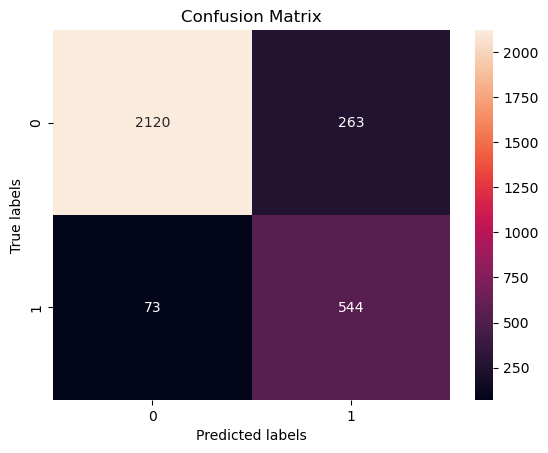

Correct guesses: 2664 out of 3000


In [18]:
# use seaborn library to plot the confusion matrix 
matrix = confusion_matrix(y_test, predicted_classes)

sns.heatmap(matrix, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Sum the diagonal element to get the total true correct values
identity = np.eye(matrix.shape[0])
diagonal = np.multiply(matrix, identity)
sum_correct = np.sum(diagonal)
sum_total = np.sum(matrix)
print(f'Correct guesses: {sum_correct:.0f} out of {sum_total:.0f}')

In [19]:
target_names = ["Class {}".format(i) for i in range(2)]
print(classification_report(y_test, predicted_classes, target_names = target_names))

              precision    recall  f1-score   support

     Class 0       0.97      0.89      0.93      2383
     Class 1       0.67      0.88      0.76       617

    accuracy                           0.89      3000
   macro avg       0.82      0.89      0.85      3000
weighted avg       0.91      0.89      0.89      3000

